Homework 4 for the MSE510/420 Course
- Instructor Sergei V. Kalinin, sergei2@utk.edu
- Please provide your name in the beginning of the notebook
- To submit the homework, please share it with my gmail address (available on Canvas)

- Run the code cell below
- If the gdown does not work due to too many requests, use the file hw3.zip on course GitHub page

In [1]:
!gdown https://drive.google.com/uc?id=1UC6bu5nVFRBhHIL698jk0zt3AuDqREkV
!unzip hw3.zip

Downloading...
From: https://drive.google.com/uc?id=1UC6bu5nVFRBhHIL698jk0zt3AuDqREkV
To: /content/hw3.zip
100% 9.96k/9.96k [00:00<00:00, 38.3MB/s]
Archive:  hw3.zip
  inflating: hw3p1.csv               
  inflating: hw3p2.csv               
  inflating: hw3p3.csv               


Now you have created 3 csv files, named hw3p1, hw3p2, and hw3p3 respectively. Load the file hw3p1 into Pandas DataFrame. It will contain three sets of data representing x and corresponding f(x). There are three sets of data overall.

**NAME: Pablo Ruiz Crespo**

Problem 1. Fit the first set of data. Please try to find equation that can explain whole data set (not spline)

      x          y  x.1        y.1  x.2        y.2
0   0.0  -0.130805  0.0   0.005324  0.0   0.773195
1   0.1   0.868900  0.1   0.794294  0.1   0.236410
2   0.2   0.765312  0.2   0.964300  0.2   0.754516
3   0.3   0.814069  0.3   1.725895  0.3   0.307927
4   0.4   0.629915  0.4   1.198981  0.4   0.027610
5   0.5   1.606064  0.5   2.312802  0.5   0.429926
6   0.6   1.713820  0.6   2.441119  0.6   0.191759
7   0.7   0.660414  0.7   2.490550  0.7   0.140413
8   0.8   2.487256  0.8   1.203743  0.8   0.114627
9   0.9   1.295687  0.9   1.306368  0.9   0.812548
10  1.0   2.610400  1.0   0.810414  1.0   0.122644
11  1.1   1.810565  1.1  -0.392568  1.1   0.895528
12  1.2   1.035582  1.2  -0.510562  1.2   0.901130
13  1.3   1.779125  1.3  -1.504070  1.3   1.710406
14  1.4   2.136268  1.4  -0.820086  1.4   0.999571
15  1.5   2.721441  1.5  -1.162430  1.5   1.372922
16  1.6   3.362955  1.6  -0.752115  1.6   1.673246
17  1.7   2.687203  1.7  -0.480084  1.7   0.618387
18  1.8   2.546218  1.8  -0.066

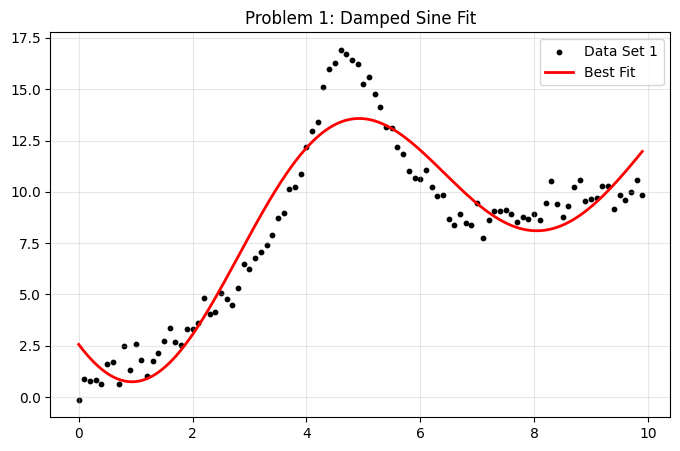

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. First Model (Damped Sine + Linear Trend)
def model_set1(x, A, decay, omega, phi, m, c):
    return A * np.exp(-decay * x) * np.sin(omega * x + phi) + m * x + c

# 2. Extract Data
df = pd.read_csv('hw3p1.csv')
x1_data = df.iloc[:, 0].values
y1_data = df.iloc[:, 1].values
print(df.to_string())



p0_guess = [10.0, 0.1, 1.4, 0.0, 1.0, 0.0]

try:
    # 4. Fit the Curve
    popt1, pcov1 = curve_fit(model_set1, x1_data, y1_data, p0=p0_guess, maxfev=10000)
    A, decay, omega, phi, m, c = popt1

    print("="*40)
    print("PROBLEM 1: FITTED PARAMETERS")
    print(f" Equation: y = {A:.3f} * e^(-{decay:.3f}x) * sin({omega:.3f}x + {phi:.3f}) + {m:.3f}x + {c:.3f}")
    print("="*40)

    # 5. Plot Result
    plt.figure(figsize=(8, 5))
    plt.scatter(x1_data, y1_data, color='black', label='Data Set 1', s=10)

    x_smooth = np.linspace(min(x1_data), max(x1_data), 500)
    plt.plot(x_smooth, model_set1(x_smooth, *popt1), color='red', linewidth=2, label='Best Fit')

    plt.title("Problem 1: Damped Sine Fit")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

except Exception as e:
    print(f"Fitting failed: {e}")

Problem 2. Fit the second set of data.  Please try to find equation that can explain whole data set (not spline)

PROBLEM 2: FITTED PARAMETERS
 Equation: y = 0.297x^2 + -0.054x + 0.371


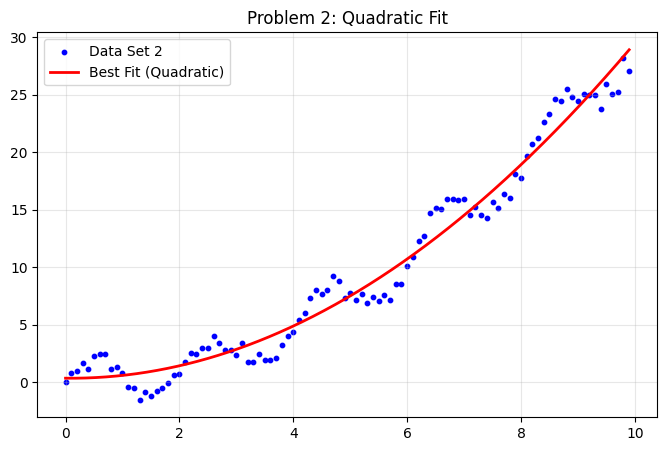

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Second Model (Quadratic / Parabola)
def model_set2(x, a, b, c):
    return a * x**2 + b * x + c

x2_data = df.iloc[:, 2].values
y2_data = df.iloc[:, 3].values

p0_guess = [0.3, 0.0, 0.0]

try:
    popt2, pcov2 = curve_fit(model_set2, x2_data, y2_data, p0=p0_guess)
    a, b, c = popt2

    print("="*40)
    print("PROBLEM 2: FITTED PARAMETERS")
    print(f" Equation: y = {a:.3f}x^2 + {b:.3f}x + {c:.3f}")
    print("="*40)

    plt.figure(figsize=(8, 5))
    plt.scatter(x2_data, y2_data, color='blue', label='Data Set 2', s=10)

    x_smooth = np.linspace(min(x2_data), max(x2_data), 500)
    plt.plot(x_smooth, model_set2(x_smooth, *popt2), color='red', linewidth=2, label='Best Fit (Quadratic)')

    plt.title("Problem 2: Quadratic Fit")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

except Exception as e:
    print(f"Fitting failed: {e}")

Problem 3. Fit the third set of data.  Please try to find equation that can explain whole data set (not spline)

PROBLEM 3: FITTED PARAMETERS
 Equation: y = 12.660 * (0.114^2 / ((x - 4.698)^2 + 0.114^2)) + 1.001x + -0.145


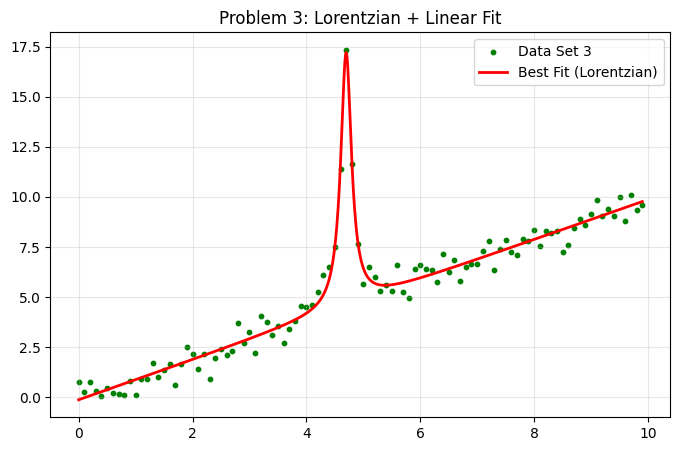

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1.Third Model (Lorentzian Peak + Linear Background)
def model_set3(x, A, x0, gamma, m, c):
    return A * (gamma**2 / ((x - x0)**2 + gamma**2)) + m * x + c

x3_data = df.iloc[:, 4].values
y3_data = df.iloc[:, 5].values


p0_guess = [12.0, 4.7, 0.1, 1.0, 0.0]

try:
    popt3, pcov3 = curve_fit(model_set3, x3_data, y3_data, p0=p0_guess)
    A, x0, gamma, m, c = popt3

    print("="*40)
    print("PROBLEM 3: FITTED PARAMETERS")
    print(f" Equation: y = {A:.3f} * ({gamma:.3f}^2 / ((x - {x0:.3f})^2 + {gamma:.3f}^2)) + {m:.3f}x + {c:.3f}")
    print("="*40)

    plt.figure(figsize=(8, 5))
    plt.scatter(x3_data, y3_data, color='green', label='Data Set 3', s=10)

    x_smooth = np.linspace(min(x3_data), max(x3_data), 1000)
    plt.plot(x_smooth, model_set3(x_smooth, *popt3), color='red', linewidth=2, label='Best Fit (Lorentzian)')

    plt.title("Problem 3: Lorentzian + Linear Fit")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

except Exception as e:
    print(f"Fitting failed: {e}")

Load the file hw3p2 into Pandas DataFrame. It will contain values of x, y, and f = f(x,y)

Problem 4: Fit f(x,y).  Please try to find equation that can explain whole data set (not spline)

PROBLEM 4: FITTED PARAMETERS
 Equation: z(x,y) = 1.000 * exp( -(x^2 + y^2) / 2.000 )


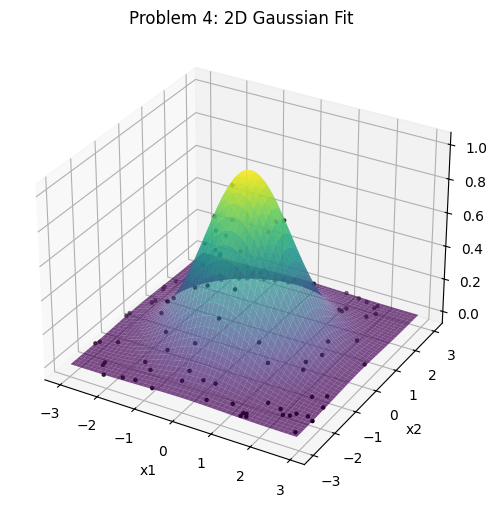

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

filename = 'hw3p2.csv'
df = pd.read_csv(filename)

x_data = df.iloc[:, 0].values
y_data = df.iloc[:, 1].values
z_data = df.iloc[:, 2].values

def model_gaussian(data, A, width):
    x, y = data
    return A * np.exp(-(x**2 + y**2) / width)


p0_guess = [1.0, 5.0]

try:
    popt, pcov = curve_fit(model_gaussian, (x_data, y_data), z_data, p0=p0_guess)
    A_fit, width_fit = popt

    print("=" * 40)
    print("PROBLEM 4: FITTED PARAMETERS")
    print(f" Equation: z(x,y) = {A_fit:.3f} * exp( -(x^2 + y^2) / {width_fit:.3f} )")
    print("=" * 40)

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(x_data, y_data, z_data, c='black', label='Data', s=5)


    x_surf = np.linspace(min(x_data), max(x_data), 50)
    y_surf = np.linspace(min(y_data), max(y_data), 50)
    X, Y = np.meshgrid(x_surf, y_surf)


    Z_fit = model_gaussian((X, Y), A_fit, width_fit)


    ax.plot_surface(X, Y, Z_fit, cmap='viridis', alpha=0.7)

    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('y')
    plt.title("Problem 4: 2D Gaussian Fit")
    plt.show()

except Exception as e:
    print(f"Fitting failed: {e}")

Load the file hw3p3 into Pandas DataFrame. It will contain values of x1, x2, and y.  

Problem 5: Explore the relationships between y and x2, y and x1, and y(x1,x2). Make you guesses about how this data was generated.

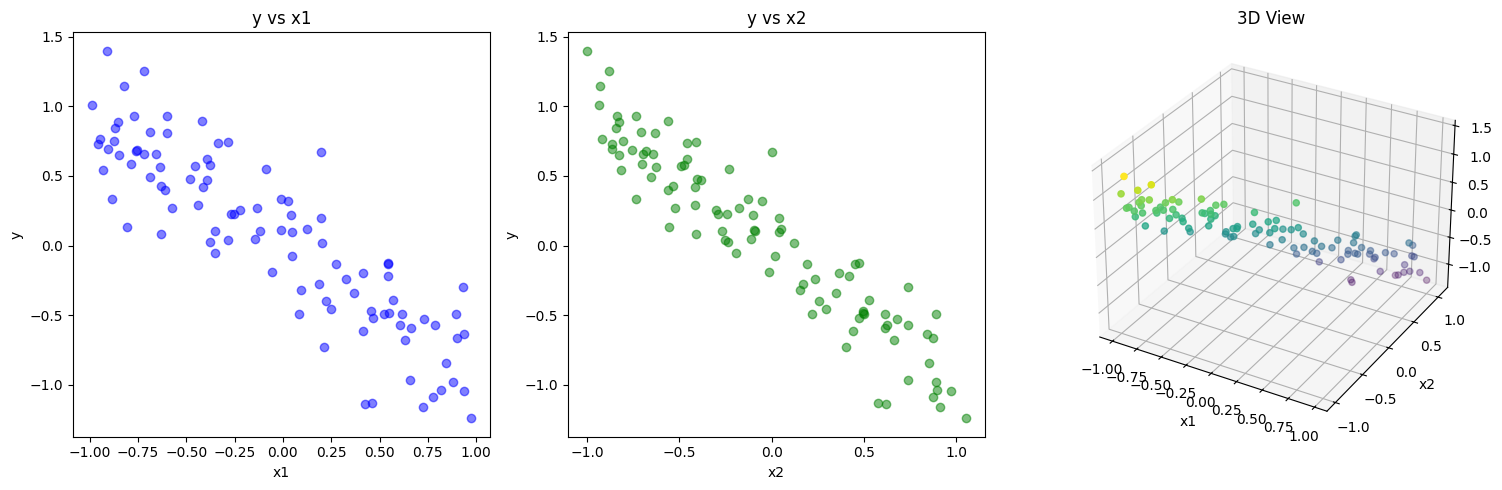

PROBLEM 5: FITTED PARAMETERS
 Equation: y(x1, x2) = 2.027*x1 + -3.027*x2 + 0.004


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

filename = 'hw3p3.csv'
df = pd.read_csv(filename)

x1_data = df.iloc[:, 0].values
x2_data = df.iloc[:, 1].values
y_data = df.iloc[:, 2].values

fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131)
ax1.scatter(x1_data, y_data, color='blue', alpha=0.5)
ax1.set_xlabel('x1')
ax1.set_ylabel('y')
ax1.set_title('y vs x1')

ax2 = fig.add_subplot(132)
ax2.scatter(x2_data, y_data, color='green', alpha=0.5)
ax2.set_xlabel('x2')
ax2.set_ylabel('y')
ax2.set_title('y vs x2')

ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(x1_data, x2_data, y_data, c=y_data, cmap='viridis')
ax3.set_xlabel('x1')
ax3.set_ylabel('x2')
ax3.set_zlabel('y')
ax3.set_title('3D View')

plt.tight_layout()
plt.show()

def model_plane(data, a, b, c):
    x1, x2 = data
    return a * x1 + b * x2 + c

p0_guess = [1.0, 1.0, 0.0]

try:
    popt, pcov = curve_fit(model_plane, (x1_data, x2_data), y_data, p0=p0_guess)
    a, b, c = popt

    print("=" * 40)
    print("PROBLEM 5: FITTED PARAMETERS")
    print(f" Equation: y(x1, x2) = {a:.3f}*x1 + {b:.3f}*x2 + {c:.3f}")
    print("=" * 40)

except Exception as e:
    print(f"Fitting failed: {e}")

Problem 6: Using ChatGPT, explore the the connection between the evolution of specific areas in physics and the development of special functions. Feel free to choose your own area, or pick one from the list below

1. Quantum Mechanics and Hermite Polynomials
Problem: Investigate the role of Hermite polynomials in the formulation of quantum mechanics. Discuss how these special functions contribute to the solutions of the quantum harmonic oscillator and their implications for understanding quantum states.

2. General Relativity and Legendre Functions
Problem: Explore the use of Legendre functions in the context of general relativity, particularly in solving the Schwarzschild solution. Analyze how these functions help describe the curvature of spacetime around spherical masses.

3. Electromagnetism and Spherical Harmonics
Problem: Study the application of spherical harmonics in solving Maxwell's equations in spherical coordinates. Discuss the significance of these special functions in understanding electromagnetic fields and potentials.

4. Fluid Dynamics and Bessel Functions
Problem: Examine how Bessel functions are utilized in fluid dynamics, especially in problems involving cylindrical symmetry. Evaluate their role in modeling flow in pipes and around obstacles.

5. Statistical Mechanics and Laguerre Polynomials
Problem: Explore the application of Laguerre polynomials in statistical mechanics, focusing on their role in the distribution functions of ideal quantum gases. Analyze how these functions aid in deriving properties like pressure and energy density.

6. Astrophysics and Associated Legendre Functions
Problem: Investigate the significance of associated Legendre functions in astrophysics, particularly in modeling gravitational potentials and describing the shapes of rotating astronomical bodies.

You can:
- Begin with a brief overview of the selected area of physics and its fundamental questions or problems.
- Use ChatGPT to explore how special functions were introduced to address specific challenges in that area.
- Analyze the mathematical properties of the special functions and how they contribute to the solutions of physical problems.
- Discuss the broader implications of these solutions for the field of physics and our understanding of the universe.
- What are your thoughts on interplay between mathematical innovation and physical discovery? how advances in one domain can spur progress in the other?

Problem 6: Quantum Mechanics and Hermite Polynomials

**1. The Physical Problem: The Quantum Harmonic Oscillator**
The Quantum Harmonic Oscillator (QHO) is a fundamental system in quantum mechanics, describing a particle trapped in a quadratic potential well ($V(x) \propto x^2$). The core challenge was solving the Schrödinger equation for this system while satisfying physical boundary conditions. Standard power series solutions naturally diverged (behaved like $e^{x^2}$ at infinity), representing a physically impossible, non-normalizable state where the particle is infinitely far away.

**2. The Mathematical Solution: Hermite Polynomials**
Hermite polynomials, developed by mathematicians in the 19th century, became the necessary solution to this physical problem. For the wavefunction to be valid (finite and approaching zero at infinity), the infinite mathematical series had to **terminate**. This termination requirement restricts the system to discrete energy values ($E_n$) and reduces the infinite series to finite polynomials known as **Hermite Polynomials ($H_n$)**.

**3. Key Mathematical Properties & Physical Meaning**
* **Orthogonality:**
    $$\int_{-\infty}^{\infty} H_m(x) H_n(x) e^{-x^2} dx = 0 \quad \text{for } m \neq n$$
    This ensures that quantum energy states are distinct and independent, allowing them to form an orthonormal basis for complex wavefunctions.
* **Parity (Symmetry):** $H_n(-x) = (-1)^n H_n(x)$. The polynomials mirror the symmetry of the potential well, dictating "selection rules" that forbid certain transitions based on symmetry conservation.
* **Nodes:** The $n$ real roots of $H_n(x)$ correspond to nodes in the wavefunction—points where the probability of finding the particle is zero. Higher $n$ means more nodes and higher kinetic energy.

**4. Broader Significance**
* **Universality:** Because stable potential minima approximate parabolas, this solution applies universally—from molecular vibrations and lattice phonons to the electromagnetic field itself (photons).
* **Zero Point Energy:** The math reveals that the lowest energy state ($n=0$) is non-zero ($\frac{1}{2}\hbar\omega$), implying that fundamental quantum systems are never completely at rest ("quantum jitter").

**5. Interplay of Math and Physics**
This case exemplifies "the unreasonable effectiveness of mathematics." Abstract 19th-century math (Hermite polynomials) existed for decades before it was found to perfectly describe 20th-century quantum reality. Physical constraints (normalizability) forced the selection of specific mathematical tools, eventually leading to the "ladder operators" that underpin modern Quantum Field Theory (QFT).